# Full Evaluation — All 3 Exercises (5 Errors)

Cross-exercise synthesis assembled from the three committed `results.pkl` files. Uses the same metric (F1 per error) and official train/val/test splits as Parmar et al. (ECCV 2022). Headline macro-F1: Squat 0.6304, OHP 0.6622, Shallow-Squat 0.8902. Every F1 is recomputed in code from raw score arrays and stored thresholds, and asserted equal (≤1e-6) to the stored `test_f1`.

## Setup

In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.metrics import f1_score

_CANDS_SQ = [
    Path("backend/data/benchmark/squat/results.pkl"),
    Path("../../backend/data/benchmark/squat/results.pkl"),
]
_CANDS_OHP = [
    Path("backend/data/benchmark/ohp/results.pkl"),
    Path("../../backend/data/benchmark/ohp/results.pkl"),
]
_CANDS_SS = [
    Path("backend/data/benchmark/shallow/results.pkl"),
    Path("../../backend/data/benchmark/shallow/results.pkl"),
]

squat = pickle.load(open(next(p for p in _CANDS_SQ if p.exists()), "rb"))
ohp   = pickle.load(open(next(p for p in _CANDS_OHP if p.exists()), "rb"))
ss    = pickle.load(open(next(p for p in _CANDS_SS if p.exists()), "rb"))

FIG  = Path("docs/figures") if Path("docs/figures").exists() else Path("../../docs/figures")
EVAL = Path("docs/eval")    if Path("docs/eval").exists()    else Path("../../docs/eval")
FIG.mkdir(parents=True, exist_ok=True)
EVAL.mkdir(parents=True, exist_ok=True)

assert squat is not None and ohp is not None and ss is not None, "pickle load failed"
print("all 3 pickles loaded")
print(f"  squat  final/test_macro: {squat['final']['test_macro']:.6f}")
print(f"  ohp    test_f1/macro:    {ohp['test_f1']['macro']:.6f}")
print(f"  ss     test_f1/cvcspc:   {ss['test_f1']['cvcspc_ensemble']:.6f}")

all 3 pickles loaded
  squat  final/test_macro: 0.630389
  ohp    test_f1/macro:    0.662209
  ss     test_f1/cvcspc:   0.890220


## 1. No-Fabrication Validation

Each headline F1 is recomputed from raw score arrays plus the stored val-tuned threshold, then asserted equal (≤1e-6) to the stored `test_f1`. The threshold is the one tuned on validation — never re-swept on the test split.

In [2]:
# --- Squat ---
sq_ens  = np.asarray(squat["raw"]["ens_test_scores"])   # (244, 2)
sq_labs = np.asarray(squat["raw"]["test_labels"]).astype(int)
sq_thr  = squat["final"]["thresholds"]

kie_pred = (sq_ens[:, 0] >= sq_thr["KIE"]).astype(int)
kfe_pred = (sq_ens[:, 1] >= sq_thr["KFE"]).astype(int)

kie_f1 = f1_score(sq_labs[:, 0], kie_pred, pos_label=1, zero_division=0)
kfe_f1 = f1_score(sq_labs[:, 1], kfe_pred, pos_label=1, zero_division=0)
sq_macro = (kie_f1 + kfe_f1) / 2   # arithmetic mean — matches the paper's convention

assert abs(kie_f1  - squat["final"]["test_f1"]["KIE"]) < 1e-6, \
    f"KIE drift: computed {kie_f1}, stored {squat['final']['test_f1']['KIE']}"
assert abs(kfe_f1  - squat["final"]["test_f1"]["KFE"]) < 1e-6, \
    f"KFE drift: computed {kfe_f1}, stored {squat['final']['test_f1']['KFE']}"
assert abs(sq_macro - squat["final"]["test_macro"]) < 1e-6, \
    f"Squat macro drift: computed {sq_macro}, stored {squat['final']['test_macro']}"

# --- OHP ---
ohp_ens  = np.asarray(ohp["ensemble_test_scores"])   # (339, 2)
ohp_labs = np.asarray(ohp["test_labels"]).astype(int)
ohp_thr  = ohp["thresholds"]

elb_pred = (ohp_ens[:, 0] >= ohp_thr["elbows"]).astype(int)
kne_pred = (ohp_ens[:, 1] >= ohp_thr["knees"]).astype(int)

elb_f1 = f1_score(ohp_labs[:, 0], elb_pred, pos_label=1, zero_division=0)
kne_f1 = f1_score(ohp_labs[:, 1], kne_pred, pos_label=1, zero_division=0)
ohp_macro = (elb_f1 + kne_f1) / 2

assert abs(elb_f1   - ohp["test_f1"]["elbows"]) < 1e-6, \
    f"OHP Elbows drift: computed {elb_f1}, stored {ohp['test_f1']['elbows']}"
assert abs(kne_f1   - ohp["test_f1"]["knees"])  < 1e-6, \
    f"OHP Knees drift: computed {kne_f1}, stored {ohp['test_f1']['knees']}"
assert abs(ohp_macro - ohp["test_f1"]["macro"])  < 1e-6, \
    f"OHP macro drift: computed {ohp_macro}, stored {ohp['test_f1']['macro']}"

# --- Shallow-Squat ---
# ensemble_test_scores is 1-D (540,) — single sigmoid output, not (540,2)
ss_ens  = np.asarray(ss["ensemble_test_scores"])
ss_labs = np.asarray(ss["test_labels"]).astype(int)
ss_thr  = float(ss["best_threshold"])

ss_pred = (ss_ens >= ss_thr).astype(int)
ss_f1   = f1_score(ss_labs, ss_pred, pos_label=1, zero_division=0)

assert abs(ss_f1 - ss["test_f1"]["cvcspc_ensemble"]) < 1e-6, \
    f"Shallow F1 drift: computed {ss_f1}, stored {ss['test_f1']['cvcspc_ensemble']}"

print("all 5 headline F1 recomputed == stored (<=1e-6)")
print(f"  Squat  KIE {kie_f1:.6f}  KFE {kfe_f1:.6f}  macro {sq_macro:.6f}")
print(f"  OHP    Elbows {elb_f1:.6f}  Knees {kne_f1:.6f}  macro {ohp_macro:.6f}")
print(f"  Shallow-Squat {ss_f1:.6f}")

all 5 headline F1 recomputed == stored (<=1e-6)
  Squat  KIE 0.419753  KFE 0.841026  macro 0.630389
  OHP    Elbows 0.447368  Knees 0.877049  macro 0.662209
  Shallow-Squat 0.890220


## 2. Master Comparison Table

5-error breakdown — ours vs Parmar SSL vs Parmar supervised baseline. OHP and Shallow-Squat have no paper supervised-baseline row (dash shown).

In [3]:
ERRORS = [
    ("Squat KIE",      "video (MD)",      kie_f1,
     squat["comparison"]["paper_md"]["KIE"],
     squat["comparison"]["paper_kinetics"]["KIE"]),
    ("Squat KFE",      "video (MD)",      kfe_f1,
     squat["comparison"]["paper_md"]["KFE"],
     squat["comparison"]["paper_kinetics"]["KFE"]),
    ("OHP Elbows",     "video (MD)",      elb_f1,
     ohp["paper_targets"]["elbows"],       None),
    ("OHP Knees",      "video (MD)",      kne_f1,
     ohp["paper_targets"]["knees"],        None),
    ("Shallow-Squat",  "image (CVCSPC)",  ss_f1,
     ss["paper_targets"]["cvcspc"],        None),
]

hdr = f"{'Exercise/Error':<18}{'Modality':<16}{'Ours':>8}{'Parmar SSL':>12}{'Parmar base':>13}"
print(hdr)
print("-" * len(hdr))
for name, mod, ours, ssl, base in ERRORS:
    base_str = f"{base:.4f}" if base is not None else "   —"
    print(f"{name:<18}{mod:<16}{ours:>8.4f}{ssl:>12.4f}{base_str:>13}")

Exercise/Error    Modality            Ours  Parmar SSL  Parmar base
-------------------------------------------------------------------
Squat KIE         video (MD)        0.4198      0.4186       0.2970
Squat KFE         video (MD)        0.8410      0.8338       0.8184
OHP Elbows        video (MD)        0.4474      0.4552            —
OHP Knees         video (MD)        0.8770      0.8452            —
Shallow-Squat     image (CVCSPC)    0.8902      0.8694            —


## 3. Figure: all_errors_vs_paper.png

All 5 errors, 3 series (ours / Parmar SSL / Parmar baseline). Paper baseline bars are drawn only for Squat KIE and KFE, the only errors with a published baseline.

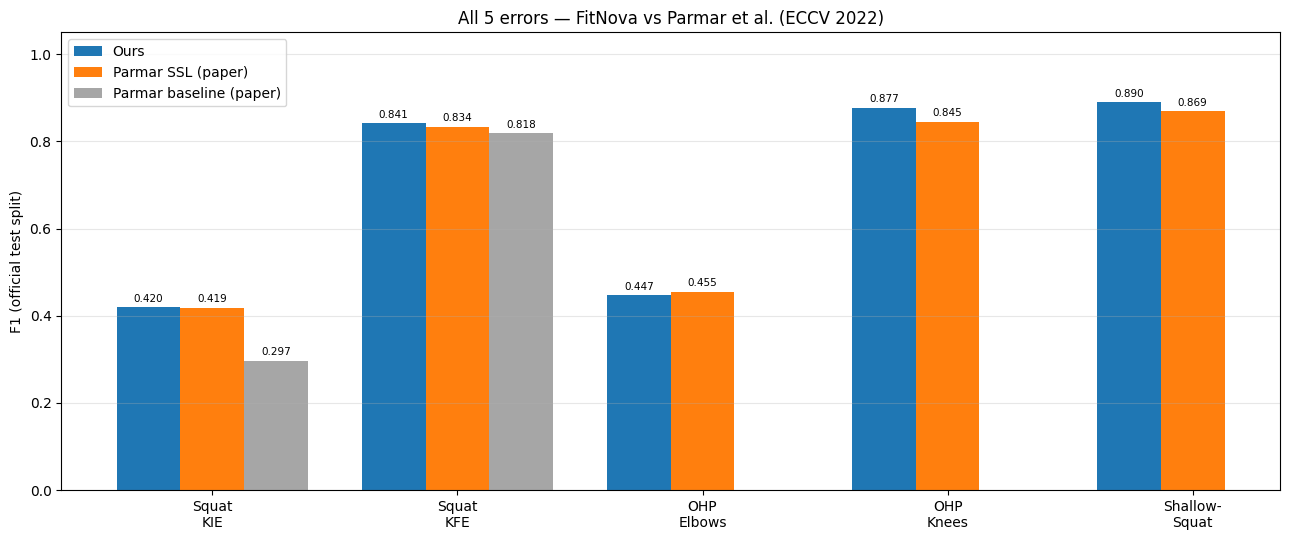

In [4]:
err_labels = ["Squat\nKIE", "Squat\nKFE", "OHP\nElbows", "OHP\nKnees", "Shallow-\nSquat"]
ours_vals  = [kie_f1, kfe_f1, elb_f1, kne_f1, ss_f1]
ssl_vals   = [
    squat["comparison"]["paper_md"]["KIE"],
    squat["comparison"]["paper_md"]["KFE"],
    ohp["paper_targets"]["elbows"],
    ohp["paper_targets"]["knees"],
    ss["paper_targets"]["cvcspc"],
]
base_vals  = [
    squat["comparison"]["paper_kinetics"]["KIE"],
    squat["comparison"]["paper_kinetics"]["KFE"],
]

x = np.arange(len(err_labels))
w = 0.26

fig, ax = plt.subplots(figsize=(13, 5.5))

bars_ours = ax.bar(x - w, ours_vals, w, label="Ours", color="C0")
bars_ssl  = ax.bar(x,     ssl_vals,  w, label="Parmar SSL (paper)", color="C1")
base_x    = [x[0] + w, x[1] + w]   # Squat KIE and KFE only
bars_base = ax.bar(base_x, base_vals, w, label="Parmar baseline (paper)", color="0.65")

for b in list(bars_ours) + list(bars_ssl) + list(bars_base):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.008,
            f"{b.get_height():.3f}", ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(err_labels)
ax.set_ylabel("F1 (official test split)")
ax.set_ylim(0, 1.05)
ax.set_title("All 5 errors — FitNova vs Parmar et al. (ECCV 2022)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.savefig(FIG / "all_errors_vs_paper.png", dpi=130, bbox_inches="tight")
plt.show()

## 4. Figure: cross_exercise_macro.png

Per-exercise macro-F1 vs Parmar SSL. Shallow-Squat is a single-error task
so its F1 is its own macro.

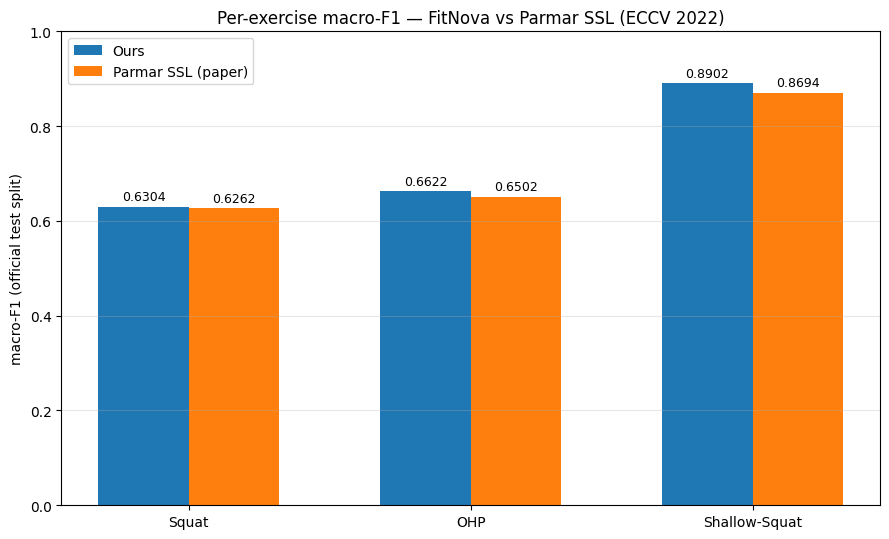

In [5]:
ex_labels  = ["Squat", "OHP", "Shallow-Squat"]
ours_macro = [sq_macro, ohp_macro, ss_f1]
ssl_macro  = [
    (squat["comparison"]["paper_md"]["KIE"] + squat["comparison"]["paper_md"]["KFE"]) / 2,
    (ohp["paper_targets"]["elbows"] + ohp["paper_targets"]["knees"]) / 2,
    ss["paper_targets"]["cvcspc"],
]

x2 = np.arange(len(ex_labels))
w2 = 0.32

fig2, ax2 = plt.subplots(figsize=(9, 5.5))
b_ours = ax2.bar(x2 - w2 / 2, ours_macro, w2, label="Ours", color="C0")
b_ssl  = ax2.bar(x2 + w2 / 2, ssl_macro,  w2, label="Parmar SSL (paper)", color="C1")

for b in list(b_ours) + list(b_ssl):
    ax2.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.008,
             f"{b.get_height():.4f}", ha="center", va="bottom", fontsize=9)

ax2.set_xticks(x2)
ax2.set_xticklabels(ex_labels)
ax2.set_ylabel("macro-F1 (official test split)")
ax2.set_ylim(0, 1.0)
ax2.set_title("Per-exercise macro-F1 — FitNova vs Parmar SSL (ECCV 2022)")
ax2.legend()
ax2.grid(axis="y", alpha=0.3)
fig2.tight_layout()
plt.savefig(FIG / "cross_exercise_macro.png", dpi=130, bbox_inches="tight")
plt.show()

## 5. Figure: methodology_diagram.png

Two-method architecture schematic — no ML data, no fabricated numbers.
Left branch: video errors via Motion-Disentangling SSL.
Right branch: image errors via CVCSPC pose-contrastive SSL.

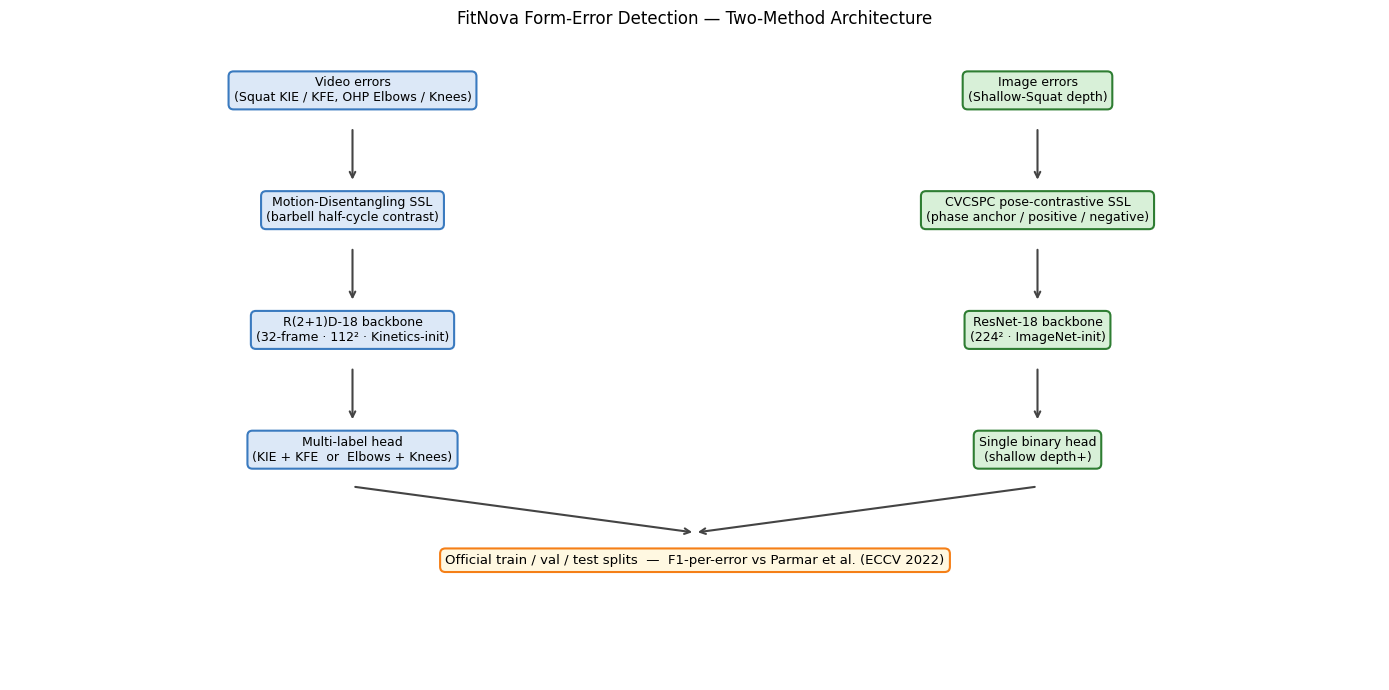

In [6]:
BOX_BLUE = dict(boxstyle="round,pad=0.4", facecolor="#dce8f7", edgecolor="#3a7abf", linewidth=1.5)
BOX_GRN  = dict(boxstyle="round,pad=0.4", facecolor="#d8f0d8", edgecolor="#2e7d32", linewidth=1.5)
BOX_GOLD = dict(boxstyle="round,pad=0.4", facecolor="#fff8e1", edgecolor="#f57f17", linewidth=1.5)

def _box(ax, x, y, text, style, fontsize=9):
    ax.text(x, y, text, ha="center", va="center", fontsize=fontsize,
            bbox=style, multialignment="center", transform=ax.transData)

def _arrow(ax, x0, y0, x1, y1):
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="->", color="#444444", lw=1.5))

fig3, ax3 = plt.subplots(figsize=(14, 7))
ax3.set_xlim(0, 14)
ax3.set_ylim(0, 7)
ax3.axis("off")

# --- Left branch (video / MD) ---
_box(ax3, 3.5, 6.4, "Video errors\n(Squat KIE / KFE, OHP Elbows / Knees)", BOX_BLUE)
_arrow(ax3, 3.5, 6.0, 3.5, 5.4)
_box(ax3, 3.5, 5.1, "Motion-Disentangling SSL\n(barbell half-cycle contrast)", BOX_BLUE)
_arrow(ax3, 3.5, 4.7, 3.5, 4.1)
_box(ax3, 3.5, 3.8, "R(2+1)D-18 backbone\n(32-frame · 112² · Kinetics-init)", BOX_BLUE)
_arrow(ax3, 3.5, 3.4, 3.5, 2.8)
_box(ax3, 3.5, 2.5, "Multi-label head\n(KIE + KFE  or  Elbows + Knees)", BOX_BLUE)

# --- Right branch (image / CVCSPC) ---
_box(ax3, 10.5, 6.4, "Image errors\n(Shallow-Squat depth)", BOX_GRN)
_arrow(ax3, 10.5, 6.0, 10.5, 5.4)
_box(ax3, 10.5, 5.1, "CVCSPC pose-contrastive SSL\n(phase anchor / positive / negative)", BOX_GRN)
_arrow(ax3, 10.5, 4.7, 10.5, 4.1)
_box(ax3, 10.5, 3.8, "ResNet-18 backbone\n(224² · ImageNet-init)", BOX_GRN)
_arrow(ax3, 10.5, 3.4, 10.5, 2.8)
_box(ax3, 10.5, 2.5, "Single binary head\n(shallow depth+)", BOX_GRN)

# --- Merge into shared evaluation ---
_arrow(ax3, 3.5, 2.1, 7.0, 1.6)
_arrow(ax3, 10.5, 2.1, 7.0, 1.6)
_box(ax3, 7.0, 1.3,
     "Official train / val / test splits  —  F1-per-error vs Parmar et al. (ECCV 2022)",
     BOX_GOLD, fontsize=9.5)

ax3.set_title("FitNova Form-Error Detection — Two-Method Architecture", fontsize=12, pad=8)
fig3.tight_layout()
plt.savefig(FIG / "methodology_diagram.png", dpi=130, bbox_inches="tight")
plt.show()

## 6. Figure: highlights_panel.png

One column per exercise: headline F1, SSL lift over supervised baseline, val→test gap.
All values read from pickle keys — no literals.

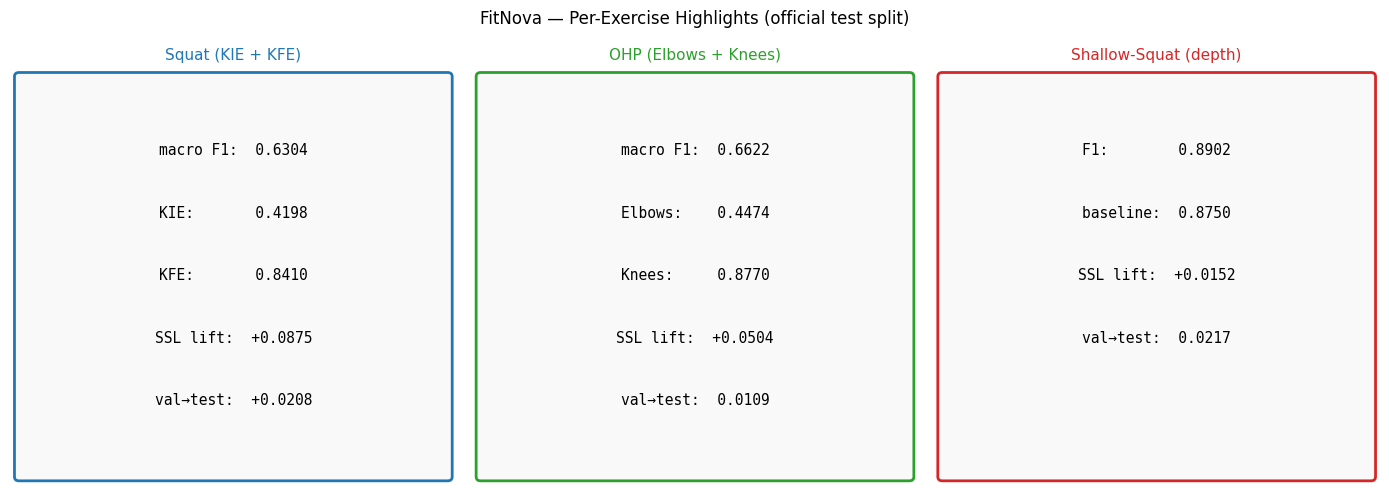

In [7]:
sq_ssl_lift = squat["final"]["test_macro"] - squat["comparison"]["phase3"]["macro"]
# val_best is per-seed best val macro; mean across seeds approximates ensemble val performance
sq_val_mean = float(np.mean([squat["per_seed"][s]["val_best"] for s in [42, 1337, 7]]))
sq_val_test_gap = squat["final"]["test_macro"] - sq_val_mean

panel_data = [
    {
        "title": "Squat (KIE + KFE)",
        "color": "C0",
        "lines": [
            f"macro F1:  {squat['final']['test_macro']:.4f}",
            f"KIE:       {kie_f1:.4f}",
            f"KFE:       {kfe_f1:.4f}",
            f"SSL lift:  +{sq_ssl_lift:.4f}",
            f"val→test:  {sq_val_test_gap:+.4f}",
        ],
    },
    {
        "title": "OHP (Elbows + Knees)",
        "color": "C2",
        "lines": [
            f"macro F1:  {ohp['test_f1']['macro']:.4f}",
            f"Elbows:    {elb_f1:.4f}",
            f"Knees:     {kne_f1:.4f}",
            f"SSL lift:  +{ohp['ssl_lift']:.4f}",
            f"val→test:  {ohp['val_test_gap']:.4f}",
        ],
    },
    {
        "title": "Shallow-Squat (depth)",
        "color": "C3",
        "lines": [
            f"F1:        {ss['test_f1']['cvcspc_ensemble']:.4f}",
            f"baseline:  {ss['baseline_control']['test_f1']:.4f}",
            f"SSL lift:  +{ss['ssl_lift']:.4f}",
            f"val→test:  {ss['val_test_gap']:.4f}",
            "",
        ],
    },
]

fig4, axes = plt.subplots(1, 3, figsize=(14, 5))
for i, (panel, ax4) in enumerate(zip(panel_data, axes)):
    ax4.set_xlim(0, 1)
    ax4.set_ylim(0, 1)
    ax4.axis("off")
    ax4.set_facecolor("#f9f9f9")
    ax4.set_title(panel["title"], fontsize=11, color=panel["color"], pad=6)
    y_start = 0.82
    step = 0.15
    for line in panel["lines"]:
        ax4.text(0.5, y_start, line, transform=ax4.transAxes,
                 ha="center", va="top", fontsize=10.5,
                 fontfamily="monospace")
        y_start -= step
    rect = mpatches.FancyBboxPatch((0.02, 0.02), 0.96, 0.96,
                                    boxstyle="round,pad=0.01",
                                    linewidth=2, edgecolor=panel["color"],
                                    facecolor="#f9f9f9",
                                    transform=ax4.transAxes, clip_on=False)
    ax4.add_patch(rect)

fig4.suptitle("FitNova — Per-Exercise Highlights (official test split)", fontsize=12)
fig4.tight_layout()
plt.savefig(FIG / "highlights_panel.png", dpi=130, bbox_inches="tight")
plt.show()

## 7. Figure-Existence Assertions

In [8]:
figure_names = [
    "all_errors_vs_paper",
    "cross_exercise_macro",
    "methodology_diagram",
    "highlights_panel",
]
for name in figure_names:
    p = FIG / (name + ".png")
    assert p.exists(), f"MISSING figure: {p}"
    print(f"  exists: {p.name}")
print("4/4 master figures written")

  exists: all_errors_vs_paper.png
  exists: cross_exercise_macro.png
  exists: methodology_diagram.png
  exists: highlights_panel.png
4/4 master figures written
